# Alissa Ouspenskaia -- DATA 201 --- Week 5 Assignment

## Resampling Methods with the Iris Dataset

In this assignment, we will explore **bootstrap resampling, jackknife
resampling, and permutation tests** using the **Iris dataset**.

The Iris dataset contains measurements of iris flowers from three
species:

-   *Setosa*
-   *Versicolor*
-   *Virginica*

Each flower has four measurements:

-   sepal length
-   sepal width
-   petal length
-   petal width

------------------------------------

In [ ]:
# Load the dataset

import pandas as pd             # For handling data (DataFrame)
import seaborn as sns           # For visualizations
import numpy as np              # For numerical operations
import matplotlib.pyplot as plt # For plots

# IRIS is preloaded Python dataset
# https://intellipaat.com/blog/iris-dataset/
iris = sns.load_dataset("iris")
iris.head()
# type(iris)  # DataFrame

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


------------------
## Tasks

1.  Print the **number of observations** in the dataset.
2.  Print the **column names**.
3.  Count how many observations exist for each **species**.

-----------------

In [ ]:
from pandas.core import groupby

sample_n = len(iris)
print(sample_n)


print(iris.columns)

print(iris.groupby("species").count())

150
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa                50           50            50           50
versicolor            50           50            50           50
virginica             50           50            50           50


-----------
***There are 50 observations for each of the three species.***

----------

# Part 1 --- Bootstrap Resampling

We will estimate the **mean sepal length** using bootstrap resampling.

## Task 1 --- Basic Statistics

Compute the following statistics for **sepal length**:

-   mean
-   median
-   standard deviation

-------------------

In [ ]:
sepal_length_mean = iris["sepal_length"].mean()
sepal_length_median = iris["sepal_length"].median()
sepal_length_SD = iris["sepal_length"].std()
print(sepal_length_mean)
print(sepal_length_median)
print(sepal_length_SD)

5.843333333333334
5.8
0.8280661279778629


------

## Task 2 --- Bootstrap the Mean

Perform **5,000 bootstrap resamples**.

Procedure:

1.  Sample the dataset **with replacement**.
2.  Each sample must contain **150 observations**.
3.  Compute the **mean sepal length** for each resample.
4.  Store the results.
5.  Plot the **distribution of bootstrap means**.

## Task 3 --- Confidence Interval

Using the bootstrap results, compute the **95% confidence interval**
using the percentile method:

CI = \[2.5%, 97.5%\]

Report:

-   Bootstrap mean
-   Lower bound
-   Upper bound
------------

Bootstrapped Mean: 5.84
Bootstrapped Std: 0.0673
95% Confidence Intervals: [5.71, 5.97]


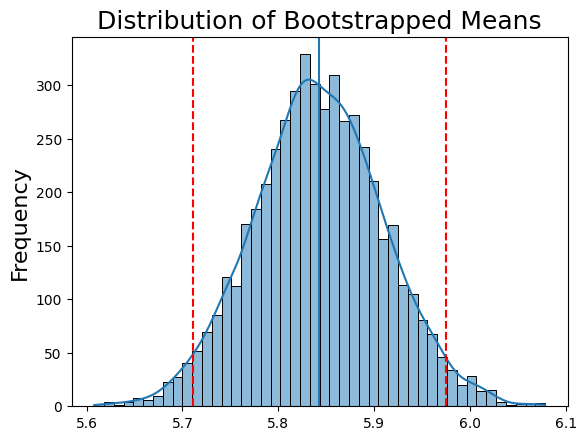

In [ ]:
# Bootstrapping IRIS dataset

boot_reps = 5000 # 5,000 bootstrap resamples
sample_size = len(iris) # Each sample must contain 150 observations

bootstrap_means = []
for b in range(boot_reps):
    # Sample from the 'sepal_length' column
    resample = np.random.choice(
        iris["sepal_length"], size = sample_size, replace = True)
    bootstrap_means.append(np.mean(resample))
bootstrap_means = np.array(bootstrap_means)

sns.histplot(bootstrap_means, kde = True, label = "Bootstrap")
plt.axvline(x = np.mean(bootstrap_means), ymin = 0, ymax = 1, linestyle = "-")
plt.title("Distribution of Bootstrapped Means", fontsize = 18)
plt.ylabel("Frequency", fontsize = 16)

lower_bound = np.percentile(bootstrap_means, 2.5)
upper_bound = np.percentile(bootstrap_means, 97.5)

plt.axvline(x=lower_bound, ymin=0, ymax=1, color='red', linestyle='--')
plt.axvline(x=upper_bound, ymin=0, ymax=1, color='red', linestyle='--')

print(f"Bootstrapped Mean: {np.mean(bootstrap_means):.3}")
print(f"Bootstrapped Std: {np.std(bootstrap_means):.3}")
print(f'95% Confidence Intervals: [{lower_bound:.3}, {upper_bound:.3}]')

-----

Bootstrapped Mean = 5.84  

95% Confidence Interval Lower Bound =  5.71  

95% Confidence Interval Upper Bound = 5.97  

--------

### Question

Why is it mathematically necessary to sample **with replacement** in
bootstrap resampling?

*The number of resamples taken is usually far higher than the sample size.  
If sample data were not replaced, we would quickly run out of data to sample.*

---------
-------------------

# Part 2 --- Jackknife Resampling

## Task 4 --- Jackknife the Mean

Create jackknife samples by removing **one observation at a time**.

Steps:

1.  For each observation i, remove it from the dataset.
2.  Compute the mean of the remaining observations.
3.  Store the result.
---------


In [ ]:
iris_sepal_length = iris["sepal_length"]  # difine outside of ftn

# Function to calculate the jackknife resampling mean
def jackknife_resampling(iris):
    n = sample_size
    jackknife_means = np.zeros(n)  # initialize n-dimensional array of zeros


    # Leave-one-out resampling
    for i in range(n):
        jackknife_sample = np.delete(iris_sepal_length, i)
        jackknife_means[i] = np.mean(jackknife_sample)

    # Jackknife estimator (mean of the means)
    jackknife_mean = np.mean(jackknife_means)

    # Bias estimation
    original_mean = np.mean(iris_sepal_length)
    bias = (n - 1) * (original_mean - jackknife_mean)
    #print(f'Bias: {bias}')

    # Variance estimation
    variance = (n - 1) * np.mean((jackknife_means - jackknife_mean) ** 2)

    return jackknife_mean, bias, variance, jackknife_means

mean, bias, variance, jackknife_means = jackknife_resampling(iris_sepal_length)
print(f"Jackknife Mean: {mean}")
print(f"Bias: {bias}")
print(f"Variance: {variance}")

Jackknife Mean: 5.843333333333334
Bias: 0.0
Variance: 0.004571290082028348


-----------
Plot the **distribution of jackknife means**.

**Visualization Tip**

Because you are removing only **one data point at a time**, the
resulting means will be extremely similar.
You may need to:

-   use a **large number of bins**, or
-   adjust `plt.xlim()` to clearly see the variation.
------------

Jackknife Mean: 5.84
Jackknife Std: 0.00554


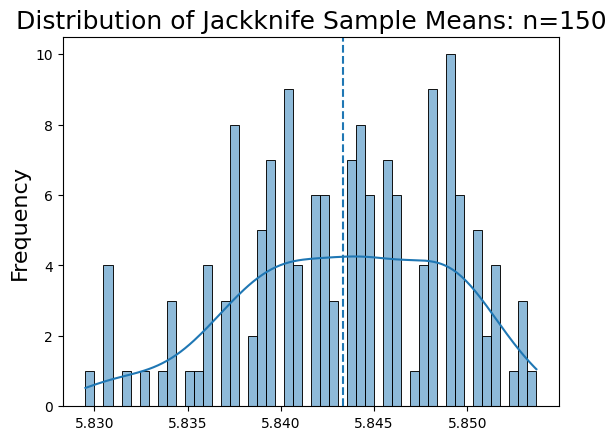

In [ ]:
sns.histplot(
    jackknife_means, kde = True, label = 'Means of Jackknife Samples', bins = 50)
plt.axvline(x=np.mean(jackknife_means), ymin=0, ymax=1, linestyle='--')
plt.title(
    f'Distribution of Jackknife Sample Means: n={sample_size}', fontsize=18)
plt.ylabel('Frequency', fontsize=16)

print(f'Jackknife Mean: {np.mean(jackknife_means):.3}')
print(f'Jackknife Std: {np.std(jackknife_means):.3}')

------------
### Question

If the dataset contains n observations,  
exactly how many jackknife
samples are created?  
  
  *n-1 samples are created*

--------------------------

-----
-----------------------------

# Part 3 --- Permutation Test

We will test whether **sepal length differs significantly between two
species**.

For this task, use:

-   **Versicolor**
-   **Virginica**

## Task 5 --- Observed Statistic

Compute the observed difference in means:

difference = mean(Versicolor) − mean(Virginica)

------------------


In [85]:
sep_len_versicolor_mean = iris[
    iris['species'] == 'versicolor']['sepal_length'].mean()
sep_len_virginica_mean = iris[
    iris['species'] == 'virginica']['sepal_length'].mean()
Tobs = sep_len_versicolor_mean - sep_len_virginica_mean
print(
    f"Test Statistic = The difference in mean sepal length (Versicolor - Virginica)\nTobs = {Tobs:.3}")

Test Statistic = The difference in mean sepal length (Versicolor - Virginica)
Tobs = -0.652


----------------

## Task 6 --- Permutation Simulation

Run **1,000 permutations**.

Procedure:

1.  Combine the two species into one dataset.
2.  **Shuffle (permute) the labels**.
3.  Split the data back into two groups of the original sizes.
4.  Compute the difference in means.
5.  Store the result.
----------

In [65]:
sepal_lengths = iris[['sepal_length','species']]
# print(sepal_lengths)
# type(sepal_lengths)  # Pandas DataFrame

sepal_lengths_combined = sepal_lengths[    # type Pandas DataFrame
    (sepal_lengths['species'] == 'versicolor') |
    (sepal_lengths['species'] == 'virginica')
]
#print(sepal_lengths_combined)

sepal_lengths_array = np.array(sepal_lengths_combined["sepal_length"])

print(sepal_lengths_array)

[7.  6.4 6.9 5.5 6.5 5.7 6.3 4.9 6.6 5.2 5.  5.9 6.  6.1 5.6 6.7 5.6 5.8
 6.2 5.6 5.9 6.1 6.3 6.1 6.4 6.6 6.8 6.7 6.  5.7 5.5 5.5 5.8 6.  5.4 6.
 6.7 6.3 5.6 5.5 5.5 6.1 5.8 5.  5.6 5.7 5.7 6.2 5.1 5.7 6.3 5.8 7.1 6.3
 6.5 7.6 4.9 7.3 6.7 7.2 6.5 6.4 6.8 5.7 5.8 6.4 6.5 7.7 7.7 6.  6.9 5.6
 7.7 6.3 6.7 7.2 6.2 6.1 6.4 7.2 7.4 7.9 6.4 6.3 6.1 7.7 6.3 6.4 6.  6.9
 6.7 6.9 5.8 6.8 6.7 6.7 6.3 6.5 6.2 5.9]


In [63]:
# alternative way to filter

import pandas as pd
import seaborn as sns

# Load the iris dataset (if not already loaded)
iris = sns.load_dataset("iris")

# Correctly combine conditions to filter for 'versicolor' OR 'virginica'
filtered_iris = iris[
    (iris['species'] == 'versicolor') |
    (iris['species'] == 'virginica')
]

print("Filtered DataFrame (only Versicolor and Virginica species):")
display(filtered_iris.head())
display(filtered_iris.tail())

print("Count of species in the filtered DataFrame:")
display(filtered_iris['species'].value_counts())


Filtered DataFrame (only Versicolor and Virginica species):


,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
51,6.4,3.2,4.5,1.5,versicolor
52,6.9,3.1,4.9,1.5,versicolor
53,5.5,2.3,4.0,1.3,versicolor
54,6.5,2.8,4.6,1.5,versicolor


,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


Count of species in the filtered DataFrame:


,count
species,
versicolor,50
virginica,50


In [76]:

n_samples = 1000

# Get the number of observations for 'versicolor' and 'virginica' from the combined dataset
# This assumes sepal_lengths_combined was correctly created in the previous cell
i_cutoff = len(sepal_lengths_combined[sepal_lengths_combined['species'] == 'versicolor'])

# Display the cutoff value for verification
print(i_cutoff)


50


In [80]:
simu_diff = []
for i in range(n_samples):  # perform permutation 1000 times
#Perform the permutation (reshuffle) on all_weights
  perm_sample = np.random.permutation(sepal_lengths_array) #each loop gives one permutation

  #Divide:  assign the permuted samples to perm_treatment and perm_control
  perm_group_A = perm_sample[:i_cutoff]  # 0 to cutoff-1
  perm_group_B = perm_sample[i_cutoff:]  # cutoff to end

  perm_diff = np.mean(perm_group_A) - np.mean(perm_group_B)
  simu_diff.append(perm_diff)



-----------
Plot the **permutation distribution**.

-------------------

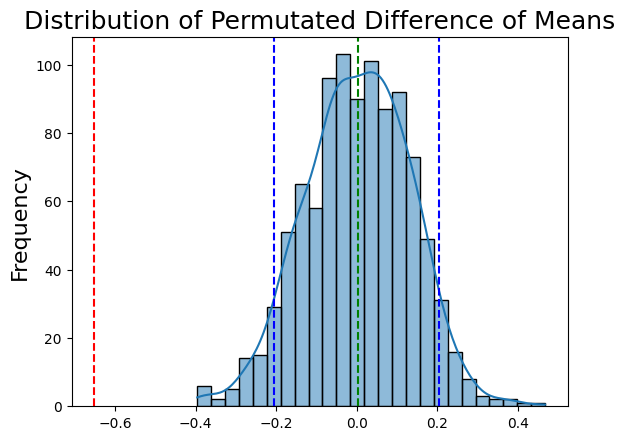

In [86]:
#Use quantiles for define the 95% confidence interval.
upper = np.quantile(simu_diff, 0.95)
lower = np.quantile(simu_diff, 0.05)

#Plot the distribution of permutated differences of means (null distribution)
sns.histplot(simu_diff, kde=True, label='Permutation')

plt.axvline(x=np.mean(simu_diff), ymin=0, ymax=1, color='green', linestyle='--')
plt.title('Distribution of Permutated Difference of Means', fontsize=18)
plt.ylabel('Frequency', fontsize=16)

# the difference in means of original groups by species
# mean_diff = Test Statistic T.obs
plt.axvline(x = Tobs, ymin=0, ymax=1, color='red', linestyle='--')


# Confidence Interval
plt.axvline(x=lower, ymin=0, ymax=1, color='blue', linestyle='--')
plt.axvline(x=upper, ymin=0, ymax=1, color='blue', linestyle='--')

----------------------------------------

## Task 7 --- p-value

Compute the p-value:

p = (number of simulated differences ≥ observed difference) / (total
simulations)

Interpret the result at α = 0.05.

*The p-value here is calculated to be 0.000.  
The $H_0$ is that there is no difference in sepal length between the species  
groups and that any observed differences can occur by chance.  
The permutation distribution shows that when combined, the sepal lengths appear to be normally distributed.    
Since the p-value is less than α, we have strong evidence for rejecting
$H_0$.   
The probability is very small that, given a chance model, the extreme observed results could occur.  
We therefore can conclude that the difference in sepal lengths is very likely to be explained by  
belonging to a species group rather than to chance.*

---------------------

In [94]:
#Calculate the p-value
# sum up all vals in array simu_diff when abs(observed diff) > abs(T.obs)
# then divide by the # of perms run to get proportion
p_value = np.sum(np.abs(simu_diff) > np.abs(Tobs)) / 1000
print(f'p-value: {p_value:.3}')


p-value: 0.0
